In [15]:
from pathlib import Path
import json
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform

# ---------------- USER SETTINGS ----------------
ORTHO_PATH = Path("./data_set/orthomosaic/A58Segment2.tif")
OUT_DIR    = Path("./output/tiles_out/A58Segment2")

TILE_SIZE  = 512
OVERLAP    = 128
BANDS      = (1, 2, 3)     # RGB bands (1-based)

# Skip tile if invalid fraction >= this
# e.g. 0.70 means skip tiles that are 70%+ black/nodata
SKIP_INVALID_FRACTION = 0.70

# If nodata isn't set in the GeoTIFF, treat near-black pixels as invalid
BLACK_THRESH_U8 = 5        # for uint8 imagery
BLACK_THRESH_U16 = int(0.01 * 65535)  # for uint16 imagery

# Speed/robustness: compute valid bbox on a downsampled mask
MASK_MAX_SIDE = 2000       # smaller = faster; 1000–3000 is good
# ------------------------------------------------

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "images").mkdir(exist_ok=True)
(OUT_DIR / "meta").mkdir(exist_ok=True)

def compute_valid_bbox(src: rasterio.io.DatasetReader,
                       mask_max_side: int = 2000,
                       black_thr_u8: int = 5,
                       black_thr_u16: int = int(0.01 * 65535)) -> tuple[int, int, int, int]:
    """
    Returns (xmin, ymin, xmax, ymax) in FULL-RES pixel coordinates (inclusive-exclusive),
    covering the region that contains valid (non-black / non-nodata) pixels.
    Uses a downsampled read for speed.
    """
    w, h = src.width, src.height
    scale = max(w, h) / mask_max_side
    if scale < 1:
        scale = 1

    out_w = max(1, int(w / scale))
    out_h = max(1, int(h / scale))

    # Read one band as a quick mask proxy (band 1 is usually enough)
    band1 = src.read(1, out_shape=(out_h, out_w), resampling=rasterio.enums.Resampling.nearest)

    dtype = str(src.dtypes[0]) if src.dtypes else "uint8"
    thr = black_thr_u16 if "uint16" in dtype else black_thr_u8

    if src.nodata is not None:
        valid_small = band1 != src.nodata
    else:
        valid_small = band1 > thr

    if not np.any(valid_small):
        raise ValueError("No valid pixels found (mask is empty). Check nodata/black threshold.")

    rows = np.any(valid_small, axis=1)
    cols = np.any(valid_small, axis=0)

    y0_s, y1_s = np.where(rows)[0][[0, -1]]
    x0_s, x1_s = np.where(cols)[0][[0, -1]]

    # Convert from small-mask coords to full-res pixel coords
    # Use inclusive-exclusive bbox and add +1 to include last valid row/col
    x0 = int(np.floor(x0_s * scale))
    y0 = int(np.floor(y0_s * scale))
    x1 = int(np.ceil((x1_s + 1) * scale))
    y1 = int(np.ceil((y1_s + 1) * scale))

    # Clamp
    x0 = max(0, min(x0, w))
    y0 = max(0, min(y0, h))
    x1 = max(0, min(x1, w))
    y1 = max(0, min(y1, h))

    return x0, y0, x1, y1

def tile_invalid_fraction(tile: np.ndarray, nodata=None, thr_u8=5, thr_u16=int(0.01*65535)) -> float:
    """
    tile shape: (C, H, W)
    Returns fraction of invalid pixels in the tile.
    invalid = nodata (if defined) OR near-black (if nodata not defined)
    """
    # Convert to HxWxC for easier masking
    t = np.transpose(tile, (1, 2, 0))

    if nodata is not None:
        invalid = np.any(t == nodata, axis=2)
    else:
        dtype = tile.dtype
        thr = thr_u16 if dtype == np.uint16 else thr_u8
        invalid = np.all(t <= thr, axis=2)

    return float(invalid.mean())

def save_png(tile: np.ndarray, out_path: Path):
    """
    tile shape: (C, H, W). Saves as uint8 PNG.
    If data is uint16, it will be scaled to uint8 by simple min/max clip.
    """
    img = np.transpose(tile, (1, 2, 0))

    if img.dtype != np.uint8:
        # robust scale to uint8
        img_f = img.astype(np.float32)
        p2 = np.percentile(img_f, 2, axis=(0, 1))
        p98 = np.percentile(img_f, 98, axis=(0, 1))
        img_n = (img_f - p2) / (p98 - p2 + 1e-6)
        img_u8 = np.clip(img_n * 255, 0, 255).astype(np.uint8)
    else:
        img_u8 = img

    try:
        from PIL import Image
        Image.fromarray(img_u8).save(out_path)
    except ImportError:
        # fallback via rasterio PNG writer
        profile = {"driver": "PNG", "height": img_u8.shape[0], "width": img_u8.shape[1], "count": 3, "dtype": "uint8"}
        with rasterio.open(out_path, "w", **profile) as dst:
            for i in range(3):
                dst.write(img_u8[..., i], i + 1)

def tile_ortho_irregular(
    ortho_path: Path,
    out_dir: Path,
    tile_size: int = 512,
    overlap: int = 128,
    bands=(1,2,3),
    skip_invalid_fraction: float = 0.70,
):
    step = tile_size - overlap
    if step <= 0:
        raise ValueError("OVERLAP must be smaller than TILE_SIZE.")

    images_dir = out_dir / "images"
    meta_dir = out_dir / "meta"
    images_dir.mkdir(parents=True, exist_ok=True)
    meta_dir.mkdir(parents=True, exist_ok=True)

    with rasterio.open(ortho_path) as src:
        # 1) Compute bbox of valid region (cuts away huge black area)
        x0, y0, x1, y1 = compute_valid_bbox(src, mask_max_side=MASK_MAX_SIDE,
                                            black_thr_u8=BLACK_THRESH_U8,
                                            black_thr_u16=BLACK_THRESH_U16)

        print(f"Valid bbox (pixels): x[{x0},{x1}) y[{y0},{y1})")
        print(f"Cropping tiling region to: {(x1-x0)} x {(y1-y0)} pixels")

        saved = 0
        skipped = 0
        total = 0

        # 2) Tile only within bbox
        for top in range(y0, y1, step):
            for left in range(x0, x1, step):
                total += 1
                window = Window(left, top, tile_size, tile_size)

                # Skip partial tiles at the edges (keeps consistent tile size for ML)
                if (left + tile_size > src.width) or (top + tile_size > src.height):
                    skipped += 1
                    continue

                tile = src.read(bands, window=window)

                # Ensure exact size (sometimes window beyond data can reduce size)
                if tile.shape[1] != tile_size or tile.shape[2] != tile_size:
                    skipped += 1
                    continue

                inv_frac = tile_invalid_fraction(tile, nodata=src.nodata,
                                                 thr_u8=BLACK_THRESH_U8,
                                                 thr_u16=BLACK_THRESH_U16)

                if inv_frac >= skip_invalid_fraction:
                    skipped += 1
                    continue

                # 3) Save tile PNG
                tile_id = f"x{left}_y{top}"
                png_path = images_dir / f"{tile_id}.png"
                save_png(tile, png_path)

                # 4) Save georeferencing meta (JSON sidecar)
                tform = window_transform(window, src.transform)
                meta = {
                    "tile_id": tile_id,
                    "ortho": ortho_path.name,
                    "bands": list(bands),
                    "left_px": int(left),
                    "top_px": int(top),
                    "tile_size": int(tile_size),
                    "overlap": int(overlap),
                    "invalid_fraction": inv_frac,
                    "crs": src.crs.to_string() if src.crs else None,
                    "transform": [tform.a, tform.b, tform.c, tform.d, tform.e, tform.f],  # affine
                    "bounds": rasterio.windows.bounds(window, src.transform),
                }
                with open(meta_dir / f"{tile_id}.json", "w", encoding="utf-8") as f:
                    json.dump(meta, f, indent=2)

                saved += 1

        print(f"\nDone.")
        print(f"Total windows checked: {total}")
        print(f"Saved tiles: {saved}")
        print(f"Skipped tiles: {skipped}")
        print(f"Saved to: {out_dir}")

# ---- RUN ----
tile_ortho_irregular(
    ortho_path=ORTHO_PATH,
    out_dir=OUT_DIR,
    tile_size=TILE_SIZE,
    overlap=OVERLAP,
    bands=BANDS,
    skip_invalid_fraction=SKIP_INVALID_FRACTION,
)

Valid bbox (pixels): x[0,17950) y[0,15087)
Cropping tiling region to: 17950 x 15087 pixels

Done.
Total windows checked: 1880
Saved tiles: 1033
Skipped tiles: 847
Saved to: output/tiles_out/A58Segment2


In [1]:
# ============================================
# Orthomosaic → Tiles for ML labeling/training
# Requires: rasterio, numpy
# Optional: matplotlib (preview), pillow (PNG)
# Install (if needed):
#   pip install rasterio numpy matplotlib pillow
# ============================================


In [2]:
# !pip install rasterio numpy matplotlib pillow

In [3]:
# 1 - Imports & configuration

from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as window_transform


DATASETS = {
    1: ("A58Segment2_roadside",
        Path("./data_set/orthomosaic/A58Segment2_roadside.tif"),
        Path("./output/tiles_out/A58Segment2_roadside")),
    2: ("A58Segment2",
        Path("./data_set/orthomosaic/A58Segment2.tif"),
        Path("./output/tiles_out/A58Segment2")),
    3: ("G15Segment1",
        Path("./data_set/orthomosaic/G15Segment1.tif"),
        Path("./output/tiles_out/G15Segment1")),
}

print("Select dataset:")
for k, v in DATASETS.items():
    print(f"{k}) {v[0]}")

choice = int(input("Enter number: "))
name, ORTHO_PATH, OUT_DIR = DATASETS[choice]

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "images").mkdir(exist_ok=True)
(OUT_DIR / "meta").mkdir(exist_ok=True)

print(f"\nSelected: {name}")
print(f"ORTHO_PATH: {ORTHO_PATH}")
print(f"OUT_DIR: {OUT_DIR}")


TILE_SIZE  = 512          # 256 or 512 are common
OVERLAP    = 128          # 0, 64, 128... (overlap pixels). For no overlap set 0.
SKIP_EMPTY_THRESHOLD = 0.60  # skip tiles if >=90% nodata/black

# Output format:
# - "geotiff": preserves georeferencing (recommended for later GIS work)
# - "png": easy for labeling tools, but no georeferencing (we write a JSON sidecar)
OUTPUT_FORMAT = "png"     # "geotiff" or "png"

# If your ortho has many bands, choose RGB:
BANDS = (1, 2, 3)         # change if needed

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "images").mkdir(exist_ok=True)
(OUT_DIR / "meta").mkdir(exist_ok=True)

print("Config OK")


Select dataset:
1) A58Segment2_roadside
2) A58Segment2
3) G15Segment1


Enter number:  3



Selected: G15Segment1
ORTHO_PATH: data_set/orthomosaic/G15Segment1.tif
OUT_DIR: output/tiles_out/G15Segment1
Config OK


In [14]:
with rasterio.open(ORTHO_PATH) as src:
    mask = src.read(1) > 0
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]

In [9]:
# 2 — Helper functions

def compute_grid(width, height, tile_size, overlap):
    stride = tile_size - overlap
    if stride <= 0:
        raise ValueError("OVERLAP must be < TILE_SIZE")

    xs = list(range(0, max(1, width - tile_size + 1), stride))
    ys = list(range(0, max(1, height - tile_size + 1), stride))

    # ensure right/bottom edges are covered
    if xs[-1] != width - tile_size:
        xs.append(max(0, width - tile_size))
    if ys[-1] != height - tile_size:
        ys.append(max(0, height - tile_size))

    return xs, ys, stride


def empty_fraction(arr, nodata=None):
    """
    arr: (bands, H, W)
    empty pixels:
      - if nodata exists: all bands == nodata
      - else: near-black (all bands <= 2)
    """
    if nodata is not None:
        mask = np.all(arr == nodata, axis=0)
    else:
        mask = np.all(arr <= 2, axis=0)
    return float(mask.mean())


def to_uint8_rgb(arr):
    """
    Convert (bands,H,W) to uint8 for PNG.
    If already uint8, return.
    If uint16/float: percentile stretch per band.
    """
    if arr.dtype == np.uint8:
        return arr

    out = np.zeros_like(arr, dtype=np.uint8)
    for b in range(arr.shape[0]):
        band = arr[b].astype(np.float32)
        lo = np.percentile(band, 1)
        hi = np.percentile(band, 99)
        if hi <= lo:
            hi = lo + 1.0
        band = (band - lo) / (hi - lo)
        band = np.clip(band, 0, 1)
        out[b] = (band * 255).round().astype(np.uint8)
    return out


In [10]:
# 3 — Tile the orthomosaic

import json

try:
    from PIL import Image
except ImportError:
    Image = None

tiles_index = []  # will store metadata for all tiles we saved

with rasterio.open(ORTHO_PATH) as src:
    width, height = src.width, src.height
    nodata = src.nodata
    crs = src.crs
    base_transform = src.transform

    xs, ys, stride = compute_grid(width, height, TILE_SIZE, OVERLAP)

    print("Ortho size (px):", width, "x", height)
    print("Tile size:", TILE_SIZE, "Overlap:", OVERLAP, "Stride:", stride)
    print("CRS:", crs)
    print("Nodata:", nodata)

    kept = 0
    total = 0

    for y in ys:
        for x in xs:
            total += 1
            win = Window(col_off=x, row_off=y, width=TILE_SIZE, height=TILE_SIZE)

            # Read selected bands
            arr = src.read(indexes=BANDS, window=win)

            # Skip partial tiles (edges) if any
            if arr.shape[1] != TILE_SIZE or arr.shape[2] != TILE_SIZE:
                continue

            if empty_fraction(arr, nodata=nodata) >= SKIP_EMPTY_THRESHOLD:
                continue

            kept += 1
            tile_name = f"tile_x{x}_y{y}_s{TILE_SIZE}"

            # Per-tile transform (georeferencing)
            tform = window_transform(win, base_transform)

            if OUTPUT_FORMAT.lower() == "geotiff":
                out_path = OUT_DIR / "images" / f"{tile_name}.tif"
                profile = src.profile.copy()
                profile.update(
                    height=TILE_SIZE,
                    width=TILE_SIZE,
                    transform=tform,
                    count=len(BANDS),
                    compress="deflate",
                    tiled=False,
                )
                with rasterio.open(out_path, "w", **profile) as dst:
                    dst.write(arr)

            elif OUTPUT_FORMAT.lower() == "png":
                if Image is None:
                    raise ImportError("Install pillow for PNG output: pip install pillow")

                arr8 = to_uint8_rgb(arr)
                # Convert CHW -> HWC for PIL
                hwc = np.transpose(arr8, (1, 2, 0))
                out_path = OUT_DIR / "images" / f"{tile_name}.png"
                Image.fromarray(hwc).save(out_path)

            else:
                raise ValueError("OUTPUT_FORMAT must be 'geotiff' or 'png'")

            # Save metadata (so you can always map tile back to ortho)
            meta = {
                "tile_name": tile_name,
                "image_file": str(out_path.name),
                "x_off_px": int(x),
                "y_off_px": int(y),
                "tile_size_px": int(TILE_SIZE),
                "overlap_px": int(OVERLAP),
                "stride_px": int(stride),
                "bands": list(BANDS),
                "crs": str(crs),
                # Affine transform: [a, b, c, d, e, f] corresponds to:
                # x = a*col + b*row + c
                # y = d*col + e*row + f
                "transform": [tform.a, tform.b, tform.c, tform.d, tform.e, tform.f],
            }

            (OUT_DIR / "meta" / f"{tile_name}.json").write_text(json.dumps(meta, indent=2))
            tiles_index.append(meta)

print(f"Total windows considered: {total}")
print(f"Tiles saved: {kept}")
print("Tiles folder:", OUT_DIR / "images")
print("Metadata folder:", OUT_DIR / "meta")


Ortho size (px): 13103 x 10459
Tile size: 512 Overlap: 128 Stride: 384
CRS: EPSG:32610
Nodata: None
Total windows considered: 918
Tiles saved: 283
Tiles folder: output/tiles_out/G15Segment1/images
Metadata folder: output/tiles_out/G15Segment1/meta


In [11]:
# 4 — Save a single index file (useful for labeling/ML pipeline)

import json

index_path = OUT_DIR / "tiles_index.json"
index_path.write_text(json.dumps(tiles_index, indent=2))
print("Wrote:", index_path)
print("Example entry:\n", json.dumps(tiles_index[0], indent=2) if tiles_index else "No tiles saved.")


Wrote: output/tiles_out/G15Segment1/tiles_index.json
Example entry:
 {
  "tile_name": "tile_x11520_y0_s512",
  "image_file": "tile_x11520_y0_s512.png",
  "x_off_px": 11520,
  "y_off_px": 0,
  "tile_size_px": 512,
  "overlap_px": 128,
  "stride_px": 384,
  "bands": [
    1,
    2,
    3
  ],
  "crs": "EPSG:32610",
  "transform": [
    0.00661,
    0.0,
    530780.51028,
    0.0,
    -0.00661,
    5457835.81041
  ]
}


Number of tiles: 318


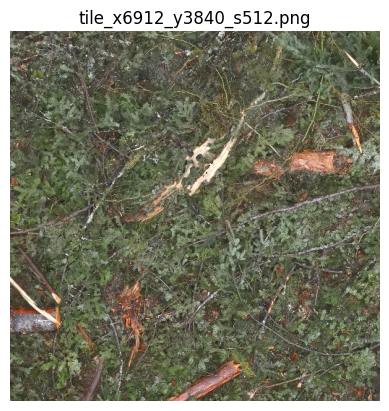

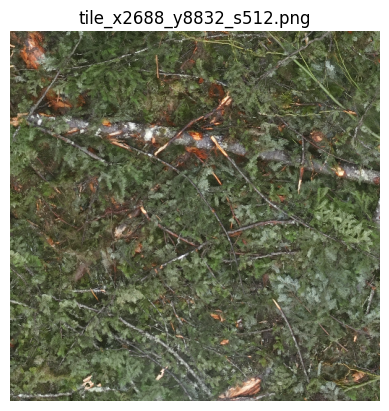

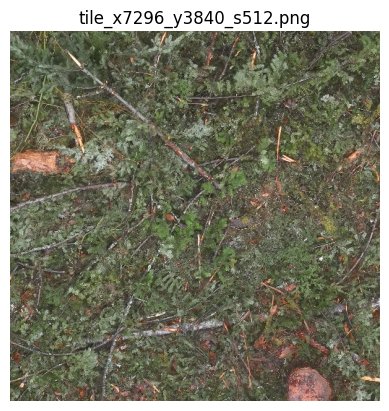

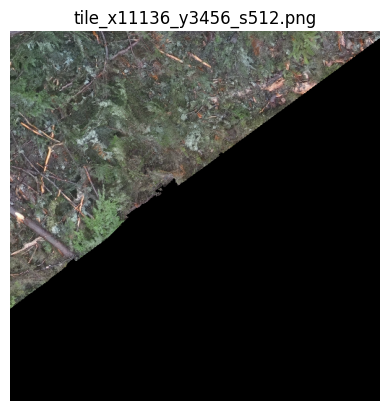

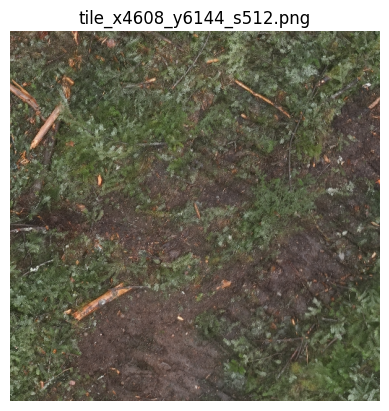

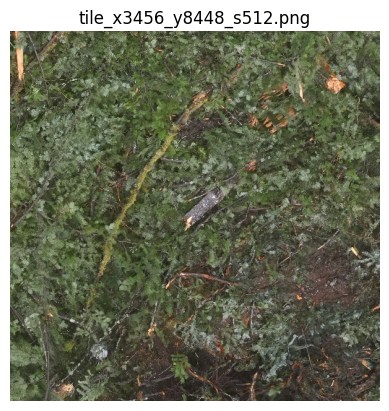

In [12]:
# 5 (optional) — Preview a few tiles

import random
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

tiles = list((OUT_DIR / "images").glob("*.png")) if OUTPUT_FORMAT == "png" else list((OUT_DIR / "images").glob("*.tif"))
print("Number of tiles:", len(tiles))

if plt and tiles:
    sample = random.sample(tiles, k=min(6, len(tiles)))
    for p in sample:
        if p.suffix.lower() == ".png":
            img = np.array(Image.open(p))
        else:
            with rasterio.open(p) as t:
                a = t.read()  # (bands,H,W)
                a8 = to_uint8_rgb(a)
                img = np.transpose(a8, (1, 2, 0))
        plt.figure()
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
        plt.show()


In [13]:
# — Next step (labeling) recommendation

"""
Labeling options (choose what you like):

1) Label in QGIS:
   - If you output GeoTIFF tiles, you can open them directly in QGIS.
   - Create polygons for good/fair/poor and rasterize to masks.

2) Label in CVAT / Label Studio:
   - PNG tiles are easiest.
   - Export masks (semantic segmentation).

Output you should aim for:
- images/: tile_x...png (or .tif)
- masks/:  tile_x...png  (single-channel uint8 with class IDs)

Once you have masks aligned with tiles, you can train UNet directly.
"""
print("Ready for labeling. Create matching masks with the same tile filenames.")


Ready for labeling. Create matching masks with the same tile filenames.
